<a href="https://colab.research.google.com/github/BrianaF691/MusicComputing-/blob/main/assignments/labAssignment4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
import IPython.display

In [36]:
def plotAudio2(signal,samplingRate,title):


   # this version expects the audio file to have already been opened by librosa


   # Adjust the x-axis to represent time


   time=np.arange(0,signal.shape[0])/samplingRate


   # Scale the y-axis to represent amplitude from -1 to 1
   excursion=max(abs(signal))
   sigNew = signal / excursion


   # Label the x and y axes with variables
   xlabel = 'Time (seconds)'
   ylabel = 'Amplitude'


   #plot the signal using the x and y axis variables
   plt.plot(time,sigNew)
   plt.xlabel(xlabel)
   plt.ylabel(ylabel)
   plt.title(title)
   plt.show()


In [24]:
def plotAudioFreqDomain(signal,samplingRate,title,winSize,specType):

    # create a normalized spectrogram
    # this includes several function calls
    # first create a basic specgrogram with librosa.stft() with the default window size (2048)
    spec = librosa.stft(signal,n_fft=winSize)
    # then make all of values in the spectrogram positive with np.abs()
    spec = np.abs(spec)
    # then scale the spectogram to be in decibels, so it better reflects how we hear librosa.amplitude_to_db()
    spec = librosa.amplitude_to_db(np.abs(librosa.stft(signal,n_fft=winSize)),ref=np.max)
    # display the normalized spectrogram with a log frequency scale
    plt.figure()
    librosa.display.specshow(spec,y_axis= specType)
    specType = 'log'
    plt.title(title)
    plt.colorbar(format='%+2.0f dB')



In [25]:
def additiveSynthesis(samplingRate,frequency,numHarmonics,seqHarm,ampExponent):

    # generate list of harmonics
    harmonics = np.arange(1,numHarmonics+1,seqHarm)

    # create a time series from 0 to 1 the inputted length
    timeSeries = np.linspace(0, 1, samplingRate)

    # create a cosine wave for the fundamental
    signal = np.cos(2.0 * np.pi * frequency * timeSeries)

    # add harmonics based on the those specified in the variable 'harmonics'
    for harm in harmonics:
        signal = signal + np.cos(2.0 * np.pi * frequency * harm * timeSeries)/harm**ampExponent

    # scale the signal to between -1 and 1
    excursion=max(abs(signal))
    signal = signal / excursion

    # plot signal
    plt.plot(timeSeries,signal)
    plt.xlabel('Time (Sec)')
    plt.ylabel('Amplitude')
    plt.title('Additive Synthesis')
    plt.plot

    return signal

In [94]:
def makeWaveforms(frequency,samplingRate,numHarmonics,waveType):
    # use an if/elif/else statement to set up the parameters for
    # the different type of waveforms based on the code in
    # additiveSynthesis.ipyn
    # if, elif (else if) and else can be used to evaluate the contents of a variable

  if waveType == 'sawtooth' :
    seqHarm = 1
    ampExponent = 1

  elif waveType == 'square' :
    seqHarm = 2
    ampExponent = 1

  elif waveType == 'triangle' :
    seqHarm = 2
    ampExponent = 2

  else :
    numHarmonics = 1
    seqHarm = 1
    ampExponent = 1

  # call additiveSynthesis() to generate a waveform

  signal = additiveSynthesis(samplingRate,frequency,numHarmonics,seqHarm,ampExponent)


  # return the generated waveform (signal)

  return signal



In [95]:
def visualizeWaveforms(frequency, samplingRate, numHarmonics, waveType, winSize, specType):
  # call makeWaveform()
  signal = makeWaveforms(frequency, samplingRate, numHarmonics, waveType)
  # test whether makeWaveforms() runs without error before you try plotting anything

  # call plotAudio2()
  plotAudio2(signal,samplingRate,'Waveform')

  # call plotAudioFreqDomain()
  plotAudioFreqDomain(signal,samplingRate,'Waveform',winSize,specType)

  # return the output of makeWaveform()
  return signal

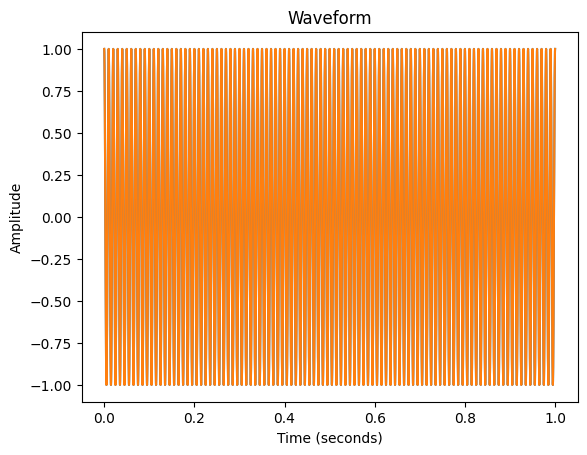

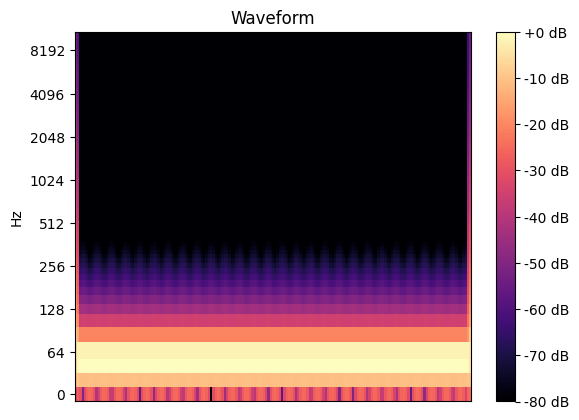

In [96]:
frequency = 100
samplingRate = 44100
numHarmonics = 100
waveType = 'sine'
winSize = 1024
specType = 'log'

signal = visualizeWaveforms(100,44100,100,'sine',1024,'log')


IPython.display.Audio(data=signal,rate=samplingRate)


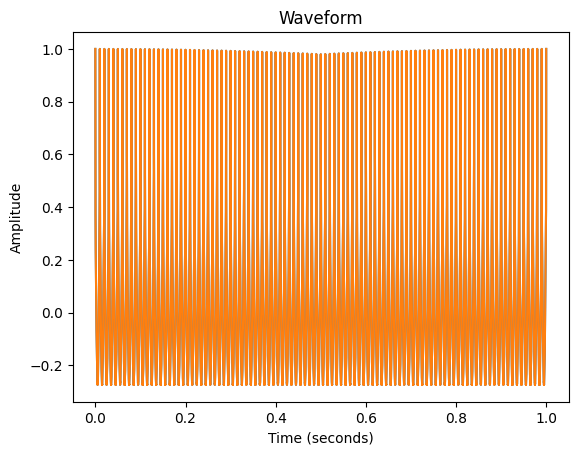

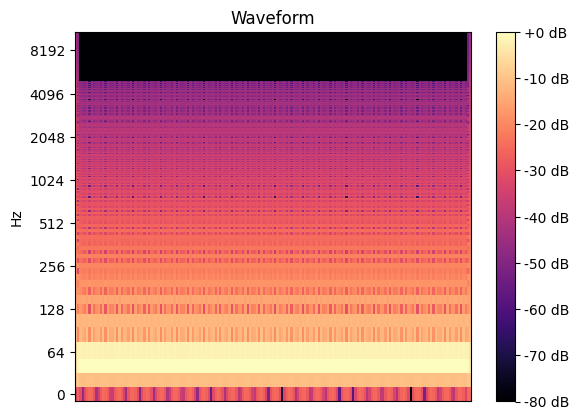

In [97]:
frequency = 100
samplingRate = 44100
numHarmonics = 100
waveType = 'sawtooth'
winSize = 1024
specType = 'log'

signal = visualizeWaveforms(100,44100,100,'sawtooth',1024,'log')

IPython.display.Audio(data=signal, rate=samplingRate)

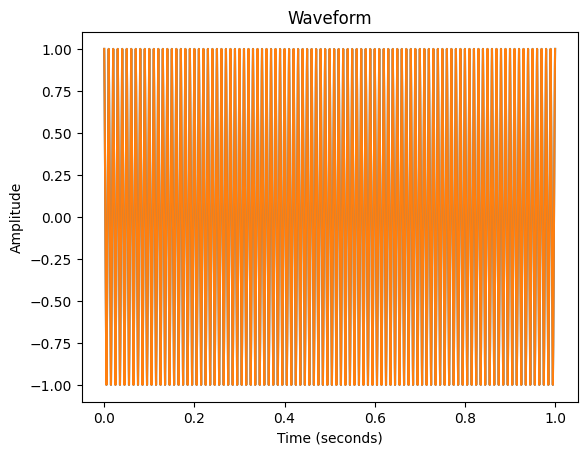

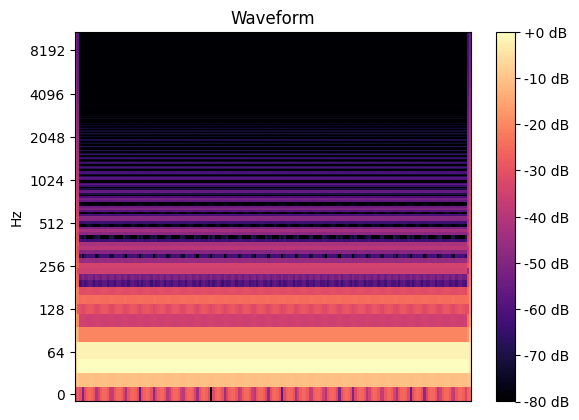

In [99]:
frequency = 100
samplingRate = 44100
numHarmonics = 100
waveType = 'triangle'
winSize = 1024
specType = 'log'

signal = visualizeWaveforms(100,44100,100,'triangle',1024,'log')
IPython.display.Audio(data=signal,rate=samplingRate)

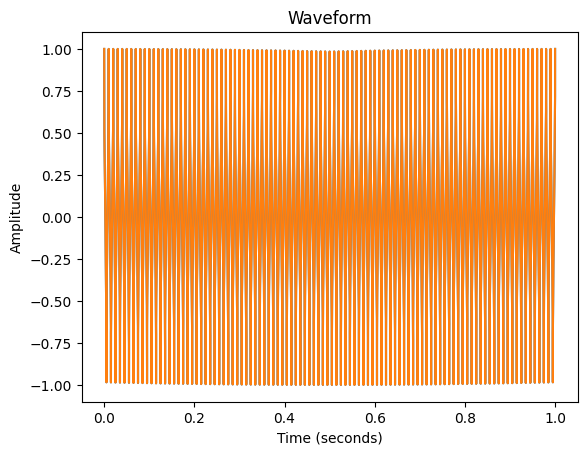

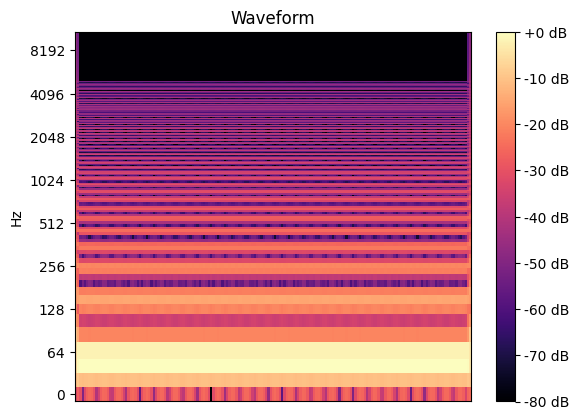

In [100]:
frequency = 100
samplingRate = 44100
numHarmonics = 100
waveType = 'square'
winSize = 1024
specType = 'log'

signal = visualizeWaveforms(100,44100,100,'square',1024,'log')
IPython.display.Audio(data=signal,rate=samplingRate)